In [1]:
import pandas as pd

# 원본 불러오기
raw = pd.read_csv("../../data/ObesityDataSet_raw_and_data_sinthetic.csv")
target_col = "NObeyesdad"
feature_cols = [c for c in raw.columns if c != target_col]

# ① 빈칸 비율 50% 이상, 상수열(nunique==1), 또는 거의 안 변하는 숫자열(std<=0.001) 제거
drop_cols = []
for c in feature_cols:
    na_ratio = raw[c].isna().mean()
    if na_ratio >= 0.5:
        drop_cols.append(c)
        continue
    if raw[c].nunique(dropna=True) == 1:
        drop_cols.append(c)
        continue
    if pd.api.types.is_numeric_dtype(raw[c]) and raw[c].std() <= 0.001:
        drop_cols.append(c)

df1 = raw.drop(columns=drop_cols)
print("제거된 열(빈칸/상수):", drop_cols)

# ② 완전 중복행을 1개로 합치기
행_전 = df1.shape[0]
df2 = df1.drop_duplicates()
print(f"중복 제거 전 {행_전}행 -> 제거 후 {df2.shape[0]}행 (제거된 행 {행_전 - df2.shape[0]}건)")

# 정제본 저장 후 다시 불러오기
df2.to_csv("results/ObesityDataSet_clean.csv", index=False)
df = pd.read_csv("results/ObesityDataSet_clean.csv")

# 전체 행 수와 열 개수
print("행", df.shape[0], "/ 열", df.shape[1])

# NObeyesdad 값별 건수와 비율
건수 = df["NObeyesdad"].value_counts()
비율 = (df["NObeyesdad"].value_counts(normalize=True) * 100).round(1)
print(pd.DataFrame({"건수": 건수, "비율(%)": 비율}))

제거된 열(빈칸/상수): []
중복 제거 전 2111행 -> 제거 후 2087행 (제거된 행 24건)
행 2087 / 열 17
                      건수  비율(%)
NObeyesdad                     
Obesity_Type_I       351   16.8
Obesity_Type_III     324   15.5
Obesity_Type_II      297   14.2
Overweight_Level_II  290   13.9
Normal_Weight        282   13.5
Overweight_Level_I   276   13.2
Insufficient_Weight  267   12.8


# 내 프로젝트 v1

# 실습 16 - 문제 정의서

## 문제 정의

**한 문장** : [보건소·1차 진료 영양사가 문진만으로 비만 위험군을 선별할 때 쓰인다.]

| 물음 | 내 답 |
|---|---|
| 누가 쓰나 | [보건소·1차 진료 영양사] |
| 무엇을 결정하나 | [문진으로 비만위험군을 판단] |
| 언제 결정하나 | [검사하기 전에 알 수 있다.] |
| 이 판단이 늦으면 | [비만위험군을 진단하면 과체중,고도비만으로 가는 경우를 줄이고 대처할 수 있다.] |

## Step 1. 문제 정의 (후보 비교)

### 후보 ① 비만 단계

**한 문장**: 보건소·1차 진료 영양 상담사가, 문진 응답을 받은 직후, 환자의 비만 단계(NObeyesdad)를 결정한다

| 물음 | 내 답 |
|---|---|
| 누가 쓰나 | 보건소·1차 진료 영양 상담사 |
| 무엇을 결정하나 | 환자의 비만 단계(NObeyesdad) |
| 언제 결정하나 | 나이·키·몸무게·식습관·운동 습관 문진 응답을 받은 직후 |
| 이 판단이 늦으면 | 비만 단계를 늦게 알게 되어 식단·운동 개입 시작이 늦어진다 |

### 후보 ② 과체중 가족력

**한 문장**: 1차 진료의가, 신규 환자의 초진 문진을 받은 시점에, 과체중 가족력 여부(family_history_with_overweight)를 결정한다

| 물음 | 내 답 |
|---|---|
| 누가 쓰나 | 1차 진료의 |
| 무엇을 결정하나 | 신규 환자의 과체중 가족력 여부(family_history_with_overweight) |
| 언제 결정하나 | 가족력을 모르는 신규 환자의 초진 문진을 받은 시점 |
| 이 판단이 늦으면 | 가족력 확인이 늦어져 위험군 선별과 예방 상담 시작이 늦어진다 |

### 후보 ③ 고칼로리 음식 잦은 섭취

**한 문장**: 공공보건 캠페인 기획자가, 생활습관 조사 응답을 취합한 시점에, 고칼로리 음식 잦은 섭취 여부(FAVC)를 결정한다

| 물음 | 내 답 |
|---|---|
| 누가 쓰나 | 공공보건 캠페인 기획자 |
| 무엇을 결정하나 | 대상자의 고칼로리 음식 잦은 섭취 여부(FAVC) |
| 언제 결정하나 | 지역 주민 생활습관 조사 응답을 취합한 시점 |
| 이 판단이 늦으면 | 캠페인 대상(고칼로리 식습관군) 선정이 늦어져 개입 시기를 놓친다 |

## Step 2. 쓰는 데이터

| 항목 | 내용 |
|---|---|
| 출처 | day06/project_v1/results/ObesityDataSet_clean.csv (중복행 제거한 정제본) |
| 규모 | 2087행 x 17열 |
| 입력으로 쓸 열 | 숫자로 된 측정 열 6개 (Age, FCVC, NCP, CH2O, FAF, TUE) — Height, Weight는 데이터 누수 점검 결과 결과 열의 사본에 가까워 제외 |
| 결과 열 (TARGET) | NObeyesdad |
| 결과 열의 값 | Insufficient_Weight / Normal_Weight / Overweight_Level_I / Overweight_Level_II / Obesity_Type_I / Obesity_Type_II / Obesity_Type_III (7종) |
| 기준선이 될 숫자 | 최다 클래스 Obesity_Type_I 351건 (16.8%) |

## Step 3. 한계

- Age, FCVC, NCP, CH2O, FAF, TUE에 정수가 아닌 값이 섞여 있다. 상당수가 SMOTE 같은 방법으로 합성된 값이라, 실제 사람의 응답 그대로가 아닐 수 있다
- 설문을 한 시점에 한 번에 걷은 데이터라, 계절이나 나이가 들면서 습관이 바뀌는 긴 흐름은 담겨 있지 않다
- 특정 습관(FAVC 등)에서 비만 단계가 높게 나오더라도, 습관과 비만 단계가 같은 시점에 함께 걷힌 것이라 그것이 원인이라고는 말할 수 없다

## 면접용 30초 설명

제가 만든 건, 보건소나 1차 진료에서 일하는 영양사가 환자 문진, 그러니까 병원에서 받는 설문 조사만 보고 비만이 될 위험이 큰 사람을 미리 가려낼 수 있게 돕는 것입니다. 여기서 비만위험군이란 아직 비만은 아니지만 습관을 보면 비만으로 갈 가능성이 큰 사람을 뜻합니다. 이게 필요한 이유는, 원래는 검사를 받아야 알 수 있는 걸 검사 전 문진 단계에서 미리 짐작할 수 있게 해주기 때문입니다. 만약 이 판단이 늦어지면, 환자가 과체중을 지나 고도비만까지 진행되고 나서야 알게 되니까, 미리 판단할 수 있으면 그 전에 대처할 기회를 놓치지 않게 됩니다.

# 실습 17 - 모델링 계획표

## 모델링 계획

| # | 하는 일 | 내 경우엔 | 막힐 것 같나 |
|---|---|---|---|
| 1 | 파일 불러오기 | [results/ObesityDataSet_clean.csv] | |
| 2 | 빈칸 채우기 | [숫자 열의 빈칸을 그 열의 중앙값으로 (확인 결과 현재는 빈칸 없음)] | |
| 3 | 결과 열을 숫자로 | [NObeyesdad 문자열 값을 0~6 숫자 라벨로 바꾸기 (LabelEncoder)] | |
| 4 | 입력과 정답 나누기 | [입력은 숫자 열 6개(Age, FCVC, NCP, CH2O, FAF, TUE) — Height, Weight는 BMI로 결과 열과 거의 겹쳐서 제외, 정답은 NObeyesdad 라벨] | |
| 5 | 학습용·시험용 나누기 | [8대 2, NObeyesdad 클래스 비율을 양쪽에 맞춰서(stratify)] | |
| 6 | 기준 모델 점수 재기 | [전부 최다 클래스(Obesity_Type_I)라고 답하는 모델] | |
| 7 | 모델 하나 학습시키기 | [표준화한 뒤 로지스틱 회귀(다중 분류)] | 막힐 것 같음 |
| 8 | 결과 읽기 | [기준 모델과 나란히 놓고 비교, 정확도만이 아니라 클래스별 재현율도 같이 본다] | 막힐 것 같음 |

### 이번 v1에서 볼 숫자

- 볼 지표 : [기준 모델 정확도 / 정확도 accuracy / 정밀도 precision / 재현율 recall]
- 이걸 보는 이유 : []

## 도전 - 입력에서 빼야 할 열이 있나 (데이터 누수 점검)

| 종류 | 있나 | 열 이름 | 어떻게 할까 |
|---|---|---|---|
| 번호·순번 열 | 없음 | - | - |
| 결과 뒤에 생기는 열 | 없음(확인 불가) | - | 이 데이터엔 시간·순서를 나타내는 열이 아예 없어서, 어떤 값이 판단 시점 이후에 찍혔는지는 이 데이터만으로 알 수 없다. 그대로 둔다 |
| 결과 열의 사본 | 있음 | Height, Weight | 둘로 BMI(Weight/Height²)를 계산하면 NObeyesdad 클래스 범위와 거의 안 겹친다. 결과 열을 숫자로 바꿔놓은 것에 가까워 입력에서 뺀다 |

- 확인한 것 : 숫자 열 8개 모두 순번 형태가 아님을 확인했고, Height·Weight로 BMI를 계산해 NObeyesdad별로 묶어보니 범위가 거의 안 겹쳤다 (Insufficient_Weight 13.00~19.08, Normal_Weight 18.49~24.91, Overweight_Level_I 22.83~28.77, Overweight_Level_II 25.71~30.36, Obesity_Type_I 29.91~35.17, Obesity_Type_II 34.05~39.79, Obesity_Type_III 36.77~50.81)
- 결론 : Height, Weight는 DROP한다. 나머지 6개(Age, FCVC, NCP, CH2O, FAF, TUE)는 입력에 그대로 쓴다

# 실습 18 - 모델링 v1

## 모델링 v1

### 문법 노트 - 코드에서 찾을 이름

| 이름 | 뜻 |
|---|---|
| features | 모델에 넣는 입력 열 목록 |
| label | 정답표 - 찾으려는 쪽이면 1, 아니면 0 |
| X / y | 입력 / 정답 |
| X_train, X_test | 학습용 입력 / 시험용 입력 |
| y_train, y_test | 학습용 정답 / 시험용 정답 |
| baseline | 기준 모델 - 학습 없이 전부 아니라고 답하는 것 |
| model | 학습시킨 모델 |
| y_pred | 모델이 내놓은 답 |
| precision / recall | 정밀도 / 재현율 |

### 내 갈래

- 갈래 : [A - 맞히기]
- 결과 열 : [result] / 관심 갈래 : [비만 유형 I Obesity Type I,비만 유형 II, Obesity Type II,비만 유형 III Obesity Type III]

- 이 기준으로 정한 이유 : [차후 비만으로 되기 전에 판단하려고 저체중,표준체중,과체중으로 0으로 설정하고 비만유형1,2,3을 1로 기록하였다.]

In [2]:
import pandas as pd  # 표 다루는 도구

# ① 정제본 파일을 불러온다
df = pd.read_csv("results/ObesityDataSet_clean.csv")

# ② 숫자로 된 열만 입력으로 쓴다
#    Height, Weight는 앞선 데이터 누수 점검에서 결과 열(NObeyesdad)의 사본(BMI)에 가까운 걸 확인해서 제외한다
입력열 = ["Age", "FCVC", "NCP", "CH2O", "FAF", "TUE"]
X = df[입력열]  # 입력(조건 열)만 따로 뗀다

# ③ 입력 열의 빈칸을 그 열의 중앙값으로 채운다
X = X.fillna(X.median())

# ④ 결과 열(NObeyesdad)이 비만 단계(Obesity_Type_I/II/III)면 1, 아니면 0인 label 열을 만든다
비만단계 = ["Obesity_Type_I", "Obesity_Type_II", "Obesity_Type_III"]  # 1로 볼 값들
y = df["NObeyesdad"].isin(비만단계).astype(int)  # 참이면 1, 거짓이면 0

print("입력 형태:", X.shape)  # (행 수, 열 수)
print(f"label 1(비만) 비율: {y.mean()*100:.1f}% ({y.sum()}건 / {len(y)}건)")

입력 형태: (2087, 6)
label 1(비만) 비율: 46.6% (972건 / 2087건)


In [3]:
from sklearn.model_selection import train_test_split  # 학습용·시험용 나누는 도구

# ⑤ 학습용·시험용을 8대 2로 나눈다 - stratify로 1 비율을 양쪽에 맞춘다
학습입력, 시험입력, 학습정답, 시험정답 = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)  # 시험용은 이후 학습에 쓰지 않는다

print(f"학습용 {len(학습입력)}건 (1 비율 {학습정답.mean()*100:.1f}%)")  # 학습용 크기·비율
print(f"시험용 {len(시험입력)}건 (1 비율 {시험정답.mean()*100:.1f}%)")  # 시험용 크기·비율

# ⑥ 기준 모델 점수 - 학습 없이 전부 0(비만 아님)이라 답했을 때 정확도
기준정확도 = (시험정답 == 0).mean()  # 실제 0인 비율이 곧 그 정확도
print(f"기준 모델 정확도: {기준정확도*100:.2f}%")

학습용 1669건 (1 비율 46.6%)
시험용 418건 (1 비율 46.7%)
기준 모델 정확도: 53.35%


In [4]:
from sklearn.preprocessing import StandardScaler  # 값을 같은 자로 맞추는 도구
from sklearn.linear_model import LogisticRegression  # 분류 모델
from sklearn.pipeline import make_pipeline  # 표준화+모델을 한 번에 묶는 도구
from sklearn.metrics import precision_score, recall_score  # 정밀도·재현율 계산 도구

# ⑦ 표준화한 뒤 로지스틱 회귀 모델 하나를 학습시킨다
모델 = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
모델.fit(학습입력, 학습정답)  # 학습용으로만 배운다

# ⑧ 시험용으로 채점한다 - 시험용은 학습에 쓰지 않는다
예측 = 모델.predict(시험입력)  # 시험용 입력만 넣어서 예측
내정확도 = (예측 == 시험정답).mean()  # 맞힌 비율

지목건수 = (예측 == 1).sum()  # 모델이 1이라고 지목한 건수
그중진짜 = ((예측 == 1) & (시험정답 == 1)).sum()  # 지목한 것 중 실제로도 1인 것
실제건수 = (시험정답 == 1).sum()  # 시험용에서 실제로 1인 건수
정밀도 = precision_score(시험정답, 예측)  # 지목한 것 중 맞은 비율
재현율 = recall_score(시험정답, 예측)  # 실제 1 중 잡아낸 비율

# 요청한 일곱 줄을 그대로 출력
print(f"기준 모델 정확도: {기준정확도*100:.2f}%")
print(f"내 모델 정확도: {내정확도*100:.2f}%")
print(f"지목한 건수: {지목건수}건")
print(f"그중 진짜: {그중진짜}건")
print(f"시험용의 실제 건수: {실제건수}건")
print(f"정밀도: {정밀도:.3f}")
print(f"재현율: {재현율:.3f}")

기준 모델 정확도: 53.35%
내 모델 정확도: 65.55%
지목한 건수: 171건
그중 진짜: 111건
시험용의 실제 건수: 195건
정밀도: 0.649
재현율: 0.569


In [5]:
from sklearn.metrics import confusion_matrix  # 네 칸으로 쪼개 세는 도구

# 지목한 건수(171)와 그중 진짜(111), 실제 건수(195)를 네 칸으로 다 풀어서 본다
맞게넘김, 헛지목, 놓침, 제대로잡음 = confusion_matrix(시험정답, 예측).ravel()  # 실제0/예측0, 실제0/예측1, 실제1/예측0, 실제1/예측1

print(f"실제 0(비만 아님) {맞게넘김 + 헛지목}건 중: 맞게 0이라 함 {맞게넘김}건 / 잘못 1이라 지목(헛지목) {헛지목}건")
print(f"실제 1(비만) {놓침 + 제대로잡음}건 중: 놓치고 0이라 함 {놓침}건 / 맞게 1이라 지목(제대로잡음) {제대로잡음}건")
print()
print(f"지목한 건수(예측=1) = 헛지목 {헛지목} + 제대로잡음 {제대로잡음} = {헛지목 + 제대로잡음}건")
print(f"그중 진짜(제대로잡음) = {제대로잡음}건")
print(f"시험용의 실제 1(비만) 건수 = 놓침 {놓침} + 제대로잡음 {제대로잡음} = {놓침 + 제대로잡음}건")

실제 0(비만 아님) 223건 중: 맞게 0이라 함 163건 / 잘못 1이라 지목(헛지목) 60건
실제 1(비만) 195건 중: 놓치고 0이라 함 84건 / 맞게 1이라 지목(제대로잡음) 111건

지목한 건수(예측=1) = 헛지목 60 + 제대로잡음 111 = 171건
그중 진짜(제대로잡음) = 111건
시험용의 실제 1(비만) 건수 = 놓침 84 + 제대로잡음 111 = 195건


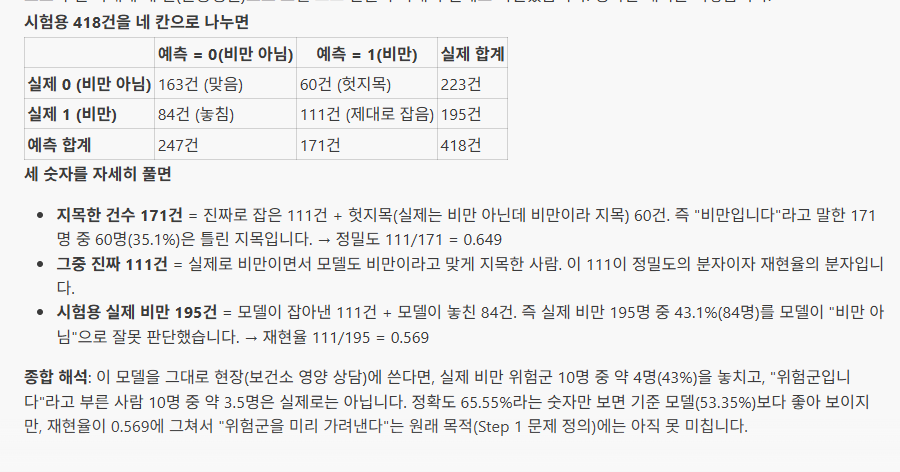

In [6]:
# 앞 모델(모델)은 그대로 둔다 - class_weight="balanced"만 추가한 새 모델을 새 이름으로 만든다
모델_가중치 = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced"))
모델_가중치.fit(학습입력, 학습정답)  # 학습용으로만 배운다

# 시험용으로 채점한다 - 시험용은 학습에 쓰지 않는다
예측_가중치 = 모델_가중치.predict(시험입력)

지목건수_가중치 = (예측_가중치 == 1).sum()  # 가중치 모델이 1이라고 지목한 건수
그중진짜_가중치 = ((예측_가중치 == 1) & (시험정답 == 1)).sum()  # 지목한 것 중 실제로도 1인 것
재현율_가중치 = recall_score(시험정답, 예측_가중치)  # 실제 1 중 잡아낸 비율

# 두 모델의 지목 건수 / 그중 진짜 / 재현율을 나란히 출력
print(f"기본 모델   - 지목 건수: {지목건수}건 / 그중 진짜: {그중진짜}건 / 재현율: {재현율:.3f}")
print(f"가중치 모델 - 지목 건수: {지목건수_가중치}건 / 그중 진짜: {그중진짜_가중치}건 / 재현율: {재현율_가중치:.3f}")

기본 모델   - 지목 건수: 171건 / 그중 진짜: 111건 / 재현율: 0.569
가중치 모델 - 지목 건수: 197건 / 그중 진짜: 122건 / 재현율: 0.626


### 도전 - 하이퍼파라미터를 바꿔본 결과

| | 지목 | 그중 진짜 | 재현율 |
|---|---|---|---|
| 손 안 댐 | [171] | [111] | [0.569] |
| 바꾼 뒤 | [197] | [122] | [0.626] |

- 알게 된 것 : [ 재현율(놓치지 않고 잡아낸 비율): 0.569 → 0.626으로 올랐다. 실제 비만 195명 중 놓치는 사람이 84명(기본)에서 73명(가중치)으로 줄었다는 뜻이다.
- 대신 지목 건수가 171건 → 197건으로 늘면서, 정밀도(지목한 것 중 진짜 비율)는 111/171=0.649에서 122/197=0.619로 떨어졌다. 헛지목이 60건(기본)에서 75건(가중치)으로 늘었다.
- 결론: class_weight="balanced"는 "놓치는 걸 줄이는 대신 헛지목을 좀 더 감수하는" 방향으로 모델을 바꾼 것이다. Step 1 문제 정의(보건소 영양 상담사가 위험군을 미리 가려낸다)처럼 놓치는 쪽이 더 부담스러운 상황이면 가중치 모델이 더 맞고, 헛지목이 부담스러운 상황(불필요한 상담 인력 낭비 등)이면 기본 모델이 더 맞다.]

# 실습 19 - 결과 한 장

## v1 결과

| | 정확도 | 지목 | 그중 진짜 | 재현율 |
|---|---|---|---|---|
| 기준 모델 (전부 비만 아님) | 53.35% | 0건 | 0건 | 0.000 |
| 내 모델 v1 | 65.55% | 171건 | 111건 | 0.569 |

- 시험용에 실제로 있던 비만 : 195건
- 한 줄 요약 : 정확도는 기준보다 12.20%p 올랐고 지목한 171건 중 111건이 실제 비만이었다(정밀도 0.649). 다만 실제 195건 중 84건은 놓쳤다(재현율 0.569)

### 다음에 할 일

1. [드문 쪽을 무겁게 세는 설정으로 지목 건수를 늘려보기](실습18 도전에서 한 번 돌려봤고 헛지목이 늘었습니다.)
2. [지목을 늘렸을 때 헛지목이 얼마나 느는지 같이 재기]
3. [재검사 한 건에 드는 비용을 알아보고, 어느 쪽이 나은지 정하기]

## 카드에 옮겨 적을 것

**3번 칸 - 사용 데이터** 비만 설문 정제본 / 2087행 x 17열 / 결과 열은 비만 아님·비만(NObeyesdad를 이진화) / 비만 972건 (46.6%)

**5번 칸 - 결과 수치** 전부 비만 아님이라 답하는 기준 모델 53.35% 대비 65.55%. 지목한 171건 중 111건이 실제 비만이었다(정밀도 0.649), 실제 195건 중 84건은 못 잡았다(재현율 0.569). 그래서 정확도만으로는 판단할 수 없는 문제였다

## 쉽게 다시 쓴 버전 - v1 결과 + 카드용 (숫자는 그대로)

### v1 결과 (쉬운 말 버전)

| | 정확도(맞힌 비율) | 지목 | 그중 진짜 | 재현율(실제 있는 대상 중 잡아낸 비율) |
|---|---|---|---|---|
| 기준 모델(아무것도 배우지 않고 한 가지로만 답하는 비교용 모델) — 전부 비만 아님 | 53.35% | 0건 | 0건 | 0.000 |
| 내 모델 v1 | 65.55% | 171건 | 111건 | 0.569 |

- 시험용에 실제로 있던 비만 : 195건
- 한 줄 요약 : 정확도(맞힌 비율)는 기준보다 12.20%p(퍼센트 두 값을 그대로 뺀 차이) 올랐고, 지목한 171건 중 111건이 실제 비만이었다(정밀도 = 지목한 것 중 진짜였던 비율 = 0.649). 다만 실제 195건 중 84건은 놓쳤다(재현율 = 실제 있는 대상 중 잡아낸 비율 = 0.569)

### 카드에 옮겨 적을 것 (쉬운 말 버전)

**3번 칸 - 사용 데이터**
비만 설문 정제본 / 2087행 x 17열 / 결과 열은 비만 아님·비만(`NObeyesdad`라는 비만 단계를 나타내는 열을, 비만이면 1 아니면 0 둘 중 하나로 이진화(값을 두 갈래로만 나누는 것)한 것) / 비만 972건 (46.6%)

**5번 칸 - 결과 수치**
전부 비만 아님이라 답하는 기준 모델(아무것도 배우지 않고 한 가지로만 답하는 비교용 모델) 53.35% 대비, 실제로 학습시킨 모델은 65.55%였다.
지목한 171건 중 111건이 실제 비만이었다(정밀도 = 지목한 것 중 진짜였던 비율 = 0.649).
실제 195건 중 84건은 못 잡았다(재현율 = 실제 있는 대상 중 잡아낸 비율 = 0.569). 그래서 정확도(맞힌 비율)만으로는 판단할 수 없는 문제였다

---
- 원인이라고 단정한 문장 확인 : 이 두 칸(v1 결과, 카드에 옮겨 적을 것) 안에서는 "~때문에", "~가 원인이다"처럼 단정하는 문장을 찾지 못해서, 이 부분은 고칠 게 없었다

- 오늘 정한 문제 : [문진 응답(생활습관)으로 비만 위험군을 먼저 가려내는 것]
- 쓴 데이터 : [비만 설문 정제본 2087행 x 17열 / 비만 972건 (46.6%)]
- 오늘 나온 숫자 : [기준 53.35% / v1 65.55% / 지목 171건 중 진짜 111건 / 재현율 0.569]
- 다음에 손댈 자리 : [재검사(상담) 한 건에 드는 비용을 알아보고, 기본 모델과 가중치 모델 중 어느 쪽이 나은지 정하기]

## 카드 8칸 - 지금까지 한 내용으로 채우기

| # | 칸 | 우리가 적은 내용 | 상태 |
|---|---|---|---|
| 1 | 제목 + 한 줄 요약 | 문진 응답(생활습관)만으로 비만 위험군을 미리 가려낸다 | 완료 (면접용 30초 설명을 한 줄로 줄임) |
| 2 | 왜 이 문제인가 | 이 판단이 늦으면 비만 단계를 늦게 알게 되어 식단·운동 개입 시작이 늦어지고, 과체중을 지나 고도비만까지 진행될 수 있다 | 완료 (문제 정의 칸에 이미 있음) |
| 3 | 사용 데이터 | 비만 설문 정제본 / 2087행 x 17열 / 결과 열은 비만 아님·비만(NObeyesdad 이진화) / 비만 972건 (46.6%) | ★ 완료 |
| 4 | 무엇을 했나 | 정제(중복행 24건 제거) → 변수(Height·Weight는 결과 열 사본이라 제외, 6개만 입력) → 모델(표준화+로지스틱 회귀, 기본/가중치 두 버전 학습) → 검증(혼동행렬로 지목·놓침·헛지목 확인) | 완료 |
| 5 | 결과 수치 | 기준 모델 53.35% 대비 v1 65.55%. 지목 171건 중 진짜 111건(정밀도 0.649), 재현율 0.569 | ★ 완료 |
| 6 | 결과 그림 | (아직 없음 - 이 노트북엔 표와 텍스트 출력만 있고 그래프는 안 그림) | 다음 회차 |
| 7 | 의사결정 가치 | 헛지목을 조금 더 감수하더라도, 놓치는 걸 줄이는 가중치 모델(class_weight="balanced")을 쓴다 | 완료 (도전 칸 결론을 한 문장으로 정리) |
| 8 | 한계와 다음 | 표본은 콜롬비아·페루·멕시코 설문이고 상당수가 SMOTE 합성값이며 한 시점 조사라 흐름이 없음. 다음엔 재검사(상담) 비용을 따져 기본/가중치 모델 중 확정 | 한계는 완료, 비용 확정은 다음 회차 |

### 도전 - 그래서 무엇을 하자는 것인가

- 모델이 비만 가능성이 높다고 지목한 사람은, 정밀 검사(체성분 검사 등)로 넘기기 전에 영양 상담 대상으로 먼저 불러들이자는 것. 지금 v1(기본 모델)로는 실제 비만 195건 중 111건만 걸러지므로, 이 상태로 현장에 바로 거는 것은 이르다